# Game Singularity: parameter-evolving neural DTB

This deterministic, two-player benchmark asks how a neural transport map loses
accuracy as trajectories approach a finite-time singularity. The exact flow is
known, so all reported errors use an independent, fixed test cloud and physical
time. Run all cells for the short correctness experiment; set
`RUN_FULL_STUDY=True` for the three-seed comparison matrix.

The implementation follows the map update in
[`parameter_evolving_neural_dtb.ipynb`](parameter_evolving_neural_dtb.ipynb)
and reuses the vector-map primitives in `run_game_dtb.py`. The separately
accumulated particle sum in
[`oscillatory_accumulated_map_parameter_evolving_dtb.ipynb`](oscillatory_accumulated_map_parameter_evolving_dtb.ipynb)
is a different state convention. Here the official state is always
$X_k(z)=T_{\theta_k}(z)$, as requested in the supplied specification.

## 1. Game, singularity, and exact solution

For $r=x_1-x_2\ne0$, the own-payoff gradient dynamics are

$$
\Pi_1=-2\log|r|,\qquad \Pi_2=\log|r|,\qquad
b(x)=\begin{pmatrix}-2/r\\-1/r\end{pmatrix}.
$$

The cross derivatives are $\partial_{x_2}b_1=-2/r^2$ and
$\partial_{x_1}b_2=1/r^2$, so this is a non-potential game. The diagonal
$\Sigma=\{x_1=x_2\}$ is a singular set, **not an equilibrium**.

Set $c=2x_2-x_1$. Then $\dot r=-1/r$ and $\dot c=0$, hence

$$
r(t)=\operatorname{sgn}(r_0)\sqrt{r_0^2-2t},\quad
t<t_*=r_0^2/2,\qquad
X(t;x_0)=\begin{pmatrix}c_0+2r(t)\\c_0+r(t)\end{pmatrix}.
$$

Independently sample $c_0\sim U[-1,1]$ and $r_0\sim U[1,2]$, then set
$x_0=(c_0+2r_0,c_0+r_0)$. The common pre-collision interval is $0\le t<0.5$.
The distribution-support minimum gap is $\sqrt{1-2t}$; a finite random cloud
has its own, slightly larger exact minimum. Both are plotted. Euclidean
distance to the diagonal is $|r|/\sqrt{2}$.


In [1]:
# Locate existing modules without changing the user's checkout or pulling changes.
# A freshly uploaded copy of this notebook also works in Colab: only the existing
# shared modules are cloned; every benchmark-specific function is visible below.
from pathlib import Path
from dataclasses import dataclass, asdict, replace
import json
import math
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.func import jvp
from IPython.display import Markdown, display

MODULE_FILES = ('dtb.py', 'run_game_dtb.py', 'network.py', 'utility.py')
candidates = [Path.cwd(), Path.cwd() / 'DTB_Game_Ver2']
EXPERIMENT_DIR = next((p for p in candidates
                       if all((p / name).is_file() for name in MODULE_FILES)), None)
if EXPERIMENT_DIR is None:
    if not Path('/content').is_dir():
        raise FileNotFoundError('Start Jupyter in DTB_Game_Ver2 or its repository root.')
    repo = Path('/content/dtb-colab-experiments')
    if not repo.exists():
        subprocess.run([
            'git', 'clone', '--depth', '1', '--branch', 'codex/game-dynamics-dtb',
            'https://github.com/sun-mengwei/dtb-colab-experiments.git', str(repo),
        ], check=True)
    EXPERIMENT_DIR = repo / 'DTB_Game_Ver2'
    if not all((EXPERIMENT_DIR / name).is_file() for name in MODULE_FILES):
        raise FileNotFoundError('The Colab checkout does not contain the required game modules.')
EXPERIMENT_DIR = EXPERIMENT_DIR.resolve()
sys.path.insert(0, str(EXPERIMENT_DIR))
from dtb import flat_params, write_flat_into_model
from run_game_dtb import ResidualMLPMap, game_dtb_basis_matrices, map_at
from network import count_trainable
from utility import save_run_data

# CPU is deliberate for this small float64 problem and works on macOS and Colab.
# Set DEVICE=torch.device('cuda') to use a Colab GPU with float64 support.
DEVICE = torch.device('cpu')
DTYPE = torch.float64
torch.set_num_threads(min(4, torch.get_num_threads()))
print('Shared modules:', EXPERIMENT_DIR)
print('PyTorch:', torch.__version__, '| device:', DEVICE, '| dtype:', DTYPE)


Shared modules: /content/dtb-colab-experiments/DTB_Game_Ver2
PyTorch: 2.11.0+cpu | device: cpu | dtype: torch.float64


## 2. Configuration and experimental design

The default reproduces Stage 1: seed 0, 512 training particles, 2048 test
particles, $h=10^{-3}$, and final time 0.45. Both fixed and gap-aware policies
run from identical initialization. The network is the width-16, depth-2 tanh
configuration from the accumulated-map example: $2\to16\to16\to2$ with an
identity skip and zero-initialized output layer (354 trainable parameters).

One seeded random subset of parameter coordinates stays fixed within each run.
At identity initialization, hidden-parameter tangent columns are zero; they
can become active after output weights move. The selected dimension and the
numerical rank are therefore different quantities. Ridge regularization
$\eta=10^{-6}$ makes the solve well-defined without hiding these zero columns.

Training samples and network/basis initialization vary across study seeds.
The independent test cloud stays fixed across **all** runs. Reported seed
standard deviations describe that training/network variability, conditional on
this test cloud; they are not confidence intervals for the population error.


In [2]:
@dataclass(frozen=True)
class Config:
    seed: int = 0
    n_train: int = 512
    n_test: int = 2048
    test_seed: int = 314159
    width: int = 16
    depth: int = 2
    basis_size: int = 128
    ridge: float = 1e-6
    h_max: float = 1e-3
    t_final: float = 0.45
    policy: str = 'fixed'
    gamma: float = 0.02
    r_stop: float = 0.02
    jacobian_chunk: int = 256
    max_steps: int = 100000
    epsilon: float | None = None  # None means the genuine singular game.

BASE = Config()
SNAPSHOT_TIMES = (0.0, 0.10, 0.25, 0.40, 0.45, 0.48, 0.49)
RUN_FULL_STUDY = False  # 3 seeds; horizons, dimensions, sample sizes, and h/2.
RUN_REGULARIZED = True
SAVE_RUN = False        # Export numerical records and the displayed figures.
STUDY_SEEDS = (0, 1, 2)
REGULARIZED_EPSILONS = (0.2, 0.1, 0.05)

def validate_config(cfg):
    for name in ('n_train', 'n_test', 'width', 'depth', 'basis_size',
                 'jacobian_chunk', 'max_steps'):
        if not isinstance(getattr(cfg, name), int) or getattr(cfg, name) < 1:
            raise ValueError(f'{name} must be a positive integer')
    for name in ('h_max', 'gamma', 'r_stop', 't_final'):
        if not math.isfinite(getattr(cfg, name)) or getattr(cfg, name) <= 0:
            raise ValueError(f'{name} must be finite and positive')
    if cfg.policy not in ('fixed', 'gap-aware'):
        raise ValueError('policy must be fixed or gap-aware')
    if not math.isfinite(cfg.ridge) or cfg.ridge <= 0:
        raise ValueError('Use a finite positive ridge for the stated ridge objective')
    if cfg.epsilon is None and cfg.t_final >= 0.5:
        raise ValueError('Unregularized runs must end strictly before t=0.5')
    if cfg.epsilon is not None and (not math.isfinite(cfg.epsilon) or cfg.epsilon <= 0):
        raise ValueError('epsilon must be finite and positive')

validate_config(BASE)
display(pd.DataFrame(asdict(BASE).items(), columns=['control', 'value']))


,control,value
0,seed,0
1,n_train,512
2,n_test,2048
3,test_seed,314159
4,width,16
5,depth,2
6,basis_size,128
7,ridge,0.000001
8,h_max,0.001
9,t_final,0.45


In [3]:
# These functions implement the mathematical benchmark, independently of DTB.
def require_finite(**values):
    for name, value in values.items():
        if not torch.isfinite(value).all():
            raise FloatingPointError(f'{name} contains a non-finite value')

def gap(x):
    if x.ndim < 1 or x.shape[-1] != 2:
        raise ValueError('Expected x[..., 2]')
    return x[..., 0] - x[..., 1]

def invariant_c(x):
    gap(x)  # Validate the last dimension consistently.
    return 2 * x[..., 1] - x[..., 0]

def singular_game_drift(x):
    """Own-payoff gradients; no denominator clipping or regularization."""
    r = gap(x)
    require_finite(x=x)
    if torch.any(r == 0):
        raise FloatingPointError('The unregularized drift is undefined on x1=x2')
    return torch.stack((-2 / r, -1 / r), dim=-1)

def sample_singular_initial(n, *, generator, device=DEVICE, dtype=DTYPE):
    # Draw pairs so a larger sample count extends the same seeded training cloud.
    # Sampling on CPU and then transferring also makes the labels portable.
    if n < 1:
        raise ValueError('n must be positive')
    uniforms = torch.rand(n, 2, generator=generator, dtype=dtype)
    c0, r0 = (2 * uniforms[:, 0] - 1).to(device), (1 + uniforms[:, 1]).to(device)
    return torch.stack((c0 + 2 * r0, c0 + r0), -1), c0, r0

def exact_collision_time(x0):
    return 0.5 * gap(x0).square()

def exact_singular_flow(x0, t):
    """Exact signed-gap flow; reject collision even if a numerical step looks finite."""
    if not math.isfinite(t) or t < 0:
        raise ValueError('t must be finite and nonnegative')
    require_finite(x0=x0)
    r0, c0 = gap(x0), invariant_c(x0)
    radicand = r0.square() - 2 * t
    if torch.any(radicand <= 0):
        raise ValueError('Requested exact time reaches or exceeds a collision')
    rt = r0.sign() * radicand.sqrt()
    return torch.stack((c0 + 2 * rt, c0 + rt), -1)

def regularized_game_drift(x, eps):
    if not math.isfinite(eps) or eps <= 0:
        raise ValueError('eps must be finite and positive')
    r = gap(x)
    require_finite(x=x)
    speed = -r / (r.square() + eps**2)
    return torch.stack((2 * speed, speed), -1)

def exact_regularized_flow(x0, t, eps):
    """Bracketed scalar bisection, vectorized over particles, in s=log(|r|).

    Solving in log-gap avoids evaluating log(0). For each particle the root is
    in [log(|r0|)-t/eps^2, log(|r0|)]. The derivative exp(2s)+eps^2 is positive,
    so bisection has one root and needs no guessed Newton initial condition.
    """
    if not math.isfinite(eps) or eps <= 0 or not math.isfinite(t) or t < 0:
        raise ValueError('Require finite eps>0 and t>=0')
    require_finite(x0=x0)
    r0, c0 = gap(x0), invariant_c(x0)
    if torch.any(r0 == 0):
        raise ValueError('This log-gap reference requires nonzero initial gaps')
    s0 = r0.abs().log()
    target = 0.5 * r0.square() + eps**2 * s0 - t
    lo, hi = s0 - t / eps**2, s0.clone()
    for _ in range(90):
        mid = (lo + hi) / 2
        residual = 0.5 * (2 * mid).exp() + eps**2 * mid - target
        lo = torch.where(residual < 0, mid, lo)
        hi = torch.where(residual >= 0, mid, hi)
    rt = r0.sign() * ((lo + hi) / 2).exp()
    return torch.stack((c0 + 2 * rt, c0 + rt), -1)

def drift_for(cfg):
    return singular_game_drift if cfg.epsilon is None else (
        lambda x: regularized_game_drift(x, cfg.epsilon))

def reference_for(cfg):
    return exact_singular_flow if cfg.epsilon is None else (
        lambda x, t: exact_regularized_flow(x, t, cfg.epsilon))

def vector_rms(v):
    # RMS of Euclidean vector norms: divide by N, not by N times dimension.
    return float(v.square().sum(-1).mean().sqrt())

def state_metrics(x, truth, x0):
    r, r_true = gap(x), gap(truth)
    return {
        'state_rmse': vector_rms(x - truth),
        'state_relative': vector_rms(x - truth) / vector_rms(truth),
        'gap_rmse': float((r - r_true).square().mean().sqrt()),
        'gap_relative': float(((r - r_true) / r_true).square().mean().sqrt()),
        'invariant_rmse': float((invariant_c(x) - invariant_c(x0)).square().mean().sqrt()),
        'min_gap': float(r.abs().min()),
    }

def require_positive_branch(x, name):
    # This experiment samples only positive gaps. A nonpositive proposal is a
    # numerical failure; do not store it as a valid state or continue its drift.
    require_finite(**{name: x})
    if torch.any(gap(x) <= 0):
        raise FloatingPointError(f'{name} reaches or crosses x1=x2 (leaves the positive-gap branch)')


## 3. Tangent projection and the actual map update

At the current parameters, evaluate the repository's restricted Jacobian
$J_k\in\mathbb R^{N\times2\times m}$. With $A=\operatorname{reshape}(J_k)/\sqrt N$
and $y=\operatorname{vec}(b(T_{\theta_k}(z)))/\sqrt N$, solve

$$
\alpha_k=\arg\min_\alpha\|A\alpha-y\|_2^2+\eta\|\alpha\|_2^2.
$$

For $A=USV^T$, use $\alpha=V\operatorname{diag}(s/(s^2+\eta))U^Ty$.
This solves the specified ridge objective without forming normal equations.
The ridge is normalized by **particle count**, so its meaning stays the same
when changing $N$. The numerical rank uses the machine-precision SVD tolerance
only for reporting; no singular values are truncated in the ridge solve.

Only selected coordinates receive $h\alpha_k$. The next official state is
$T_{\theta_{k+1}}(z)$. We also compute the local map defect

$$
\|T_{\theta_k+h\alpha_k}(z)-[T_{\theta_k}(z)+hJ_k(z)\alpha_k]\|_{L^2}.
$$

This measures nonlinear parameter-update curvature. It is **not** a best-fit
representation error or an additive decomposition of the total error. The
held-out tangent residual measures instantaneous velocity fit, direct Euler
and step halving probe time error, and the dimension sweep probes the effect
of the restricted map/tangent family. These effects can interact.

The controller uses the minimum gap over the training and monitoring test
clouds. Test values never enter the least-squares objective; they also serve
as a conservative collision monitor. This finite-cloud guard is not a proof
that the map stays away from the diagonal on the entire distribution support.


In [4]:
def ridge_tangent_solve(jacobian, target, eta):
    """Small notebook-local ridge solve; J has shape (N, 2, m)."""
    if jacobian.ndim != 3 or jacobian.shape[:2] != target.shape:
        raise ValueError('Expected J=(N,2,m) and target=(N,2)')
    if not math.isfinite(eta) or eta <= 0:
        raise ValueError('eta must be finite and positive')
    n, _, m = jacobian.shape
    a, y = jacobian.reshape(2 * n, m) / math.sqrt(n), target.reshape(-1) / math.sqrt(n)
    u, s, vh = torch.linalg.svd(a, full_matrices=False)
    alpha = vh.T @ ((s / (s.square() + eta)) * (u.T @ y))
    rank_tol = max(a.shape) * torch.finfo(a.dtype).eps * s[0]
    active = s > rank_tol
    smallest = float(s[active][-1]) if active.any() else 0.0
    sigma_max = float(s[0])
    return alpha.detach(), {
        'selected_dimension': m,
        'numerical_rank': int(active.sum()),
        'sigma_max': sigma_max,
        'sigma_min_nonzero': smallest,
        'nonzero_condition': sigma_max / smallest if smallest else float('nan'),
        # With fewer rows than columns, additional singular values are zero.
        'ridge_normal_condition': (sigma_max**2 + eta) / (
            (float(s[-1])**2 if a.shape[0] >= m else 0.0) + eta),
    }

def make_problem(cfg):
    validate_config(cfg)
    np.random.seed(cfg.seed)
    torch.manual_seed(cfg.seed)
    if DEVICE.type == 'cuda':
        torch.cuda.manual_seed_all(cfg.seed)
    # Distinct RNG streams keep sampling independent of network initialization.
    train, _, _ = sample_singular_initial(
        cfg.n_train, generator=torch.Generator().manual_seed(10000 + cfg.seed))
    test, _, _ = sample_singular_initial(
        cfg.n_test, generator=torch.Generator().manual_seed(cfg.test_seed))
    model = ResidualMLPMap(dim=2, width=cfg.width, depth=cfg.depth,
                           activation='tanh', dtype=DTYPE).to(DEVICE)
    theta, structure, _ = flat_params(model)
    assert theta.numel() == count_trainable(model)
    if cfg.basis_size > theta.numel():
        raise ValueError('basis_size exceeds the trainable parameter count')
    permutation = torch.randperm(theta.numel(), generator=torch.Generator().manual_seed(20000 + cfg.seed))
    # Prefix selection makes m=32,64,128 nested for a given seed.
    selected = permutation[:cfg.basis_size].sort().values.to(DEVICE)
    assert torch.equal(map_at(theta, train, model, structure), train)
    assert torch.equal(map_at(theta, test, model, structure), test)
    return model, theta, structure, selected, train, test

def test_tangent_velocity(theta, selected, alpha, labels, model, structure):
    # Forward-mode JVP evaluates J_test @ alpha without allocating (N_test,2,m).
    # The mathematical Jacobian is the same selected-parameter derivative used
    # in training; this is only a memory/computation optimization.
    def selected_map(values):
        return map_at(theta.index_copy(0, selected, values), labels, model, structure)
    return jvp(selected_map, (theta[selected],), (alpha,))[1].detach()

def synchronized_time():
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize(DEVICE)
    return time.perf_counter()

def storage_times(cfg):
    # Land exactly on requested snapshots, plus a modest grid for state storage.
    # Diagnostics themselves are recorded at every accepted physical time.
    values = [0.0, cfg.t_final, *np.arange(0.01, cfg.t_final, 0.01),
              *(t for t in SNAPSHOT_TIMES if t <= cfg.t_final)]
    return np.asarray(sorted(set(round(float(t), 12) for t in values)))


In [5]:
def run_dtb(cfg, *, verbose=True):
    """Parameter Euler evolution with a persistent map and fixed reference labels."""
    model, theta, structure, selected, train, test = make_problem(cfg)
    theta_initial = theta.clone()
    unselected = torch.ones(theta.numel(), dtype=torch.bool, device=DEVICE)
    unselected[selected] = False
    drift, reference = drift_for(cfg), reference_for(cfg)
    targets = storage_times(cfg)
    times, records, steps, saved_times, particles = [], [], [], [], []
    status, reason, failed_time = 'completed', '', None
    failure_proposal = None
    t, target_index = 0.0, 1
    wall_start = synchronized_time()

    # Store only accepted states. A rejected proposal lives separately in the
    # failure record so plots can never display it as a valid trajectory point.
    for k in range(cfg.max_steps + 1):
        try:
            x_train, J, J_flat = game_dtb_basis_matrices(
                theta, selected, train, model, structure, chunk=cfg.jacobian_chunk)
            x_train, J = x_train.detach(), J.detach()
            x_test = map_at(theta, test, model, structure).detach()
            require_positive_branch(x_train, 'training state')
            require_positive_branch(x_test, 'test state')
            target_velocity = drift(x_train)
            b_test = drift(x_test)
            truth = reference(test, t)
            b_truth = drift(truth)
            require_finite(theta=theta, target_velocity=target_velocity, truth=truth, b_test=b_test)
            diagnostic_failure = None
            try:
                require_finite(J=J)
                alpha, spectrum = ridge_tangent_solve(J, target_velocity, cfg.ridge)
                u_train = torch.einsum('ndm,m->nd', J, alpha)
                u_test = test_tangent_velocity(theta, selected, alpha, test, model, structure)
                require_finite(alpha=alpha, u_train=u_train, u_test=u_test)
            except (FloatingPointError, torch.linalg.LinAlgError) as error:
                # The state itself is valid even if its next tangent solve fails.
                # Retain its exact state diagnostics and mark unavailable tangent
                # diagnostics with NaN; do not attach an older time to this map.
                diagnostic_failure = str(error)
                alpha = torch.full((cfg.basis_size,), float('nan'), device=DEVICE, dtype=DTYPE)
                u_train, u_test = torch.full_like(x_train, float('nan')), torch.full_like(x_test, float('nan'))
                spectrum = {key: float('nan') for key in (
                    'sigma_max', 'sigma_min_nonzero', 'nonzero_condition', 'ridge_normal_condition')}
                spectrum.update(selected_dimension=cfg.basis_size, numerical_rank=0)
            assert J.shape == (cfg.n_train, 2, cfg.basis_size)
            assert J_flat.shape == (2 * cfg.n_train, cfg.basis_size)
            assert alpha.shape == (cfg.basis_size,)
        except (FloatingPointError, torch.linalg.LinAlgError) as error:
            status, reason, failed_time = 'failed', str(error), t
            break

        if verbose and k == 0:
            print(f'J_train={tuple(J.shape)}, stacked={tuple(J_flat.shape)}, '
                  f'alpha={tuple(alpha.shape)}, parameters={theta.numel()}, '
                  f'initial numerical rank={spectrum["numerical_rank"]}')
        min_gap = min(float(gap(x_train).min()), float(gap(x_test).min()))
        train_residual = vector_rms(u_train - target_velocity)
        test_residual = vector_rms(u_test - b_test)
        record = {
            'time': t, **state_metrics(x_test, truth, test), **spectrum,
            'min_gap_monitor': min_gap,
            'exact_min_gap_test': float(gap(truth).abs().min()),
            'support_min_gap': math.sqrt(1 - 2 * t) if cfg.epsilon is None else float('nan'),
            'drift_rms': vector_rms(b_test), 'exact_drift_rms': vector_rms(b_truth),
            'velocity_rmse': vector_rms(u_test - b_truth),
            'drift_velocity_rmse': vector_rms(b_test - b_truth),
            'train_residual': train_residual, 'test_residual': test_residual,
            'train_relative_residual': train_residual / vector_rms(target_velocity),
            'test_relative_residual': test_residual / vector_rms(b_test),
            'alpha_norm': float(alpha.norm()),
            'diagnostic_failure': diagnostic_failure or '',
            'elapsed_seconds': synchronized_time() - wall_start,
        }
        times.append(t)
        records.append(record)
        if np.isclose(t, targets, atol=1e-12, rtol=0).any():
            saved_times.append(t)
            particles.append(x_test.cpu().clone())
        if diagnostic_failure is not None:
            status, reason, failed_time = 'failed', diagnostic_failure, t
            break
        if t >= cfg.t_final - 1e-14:
            break
        if min_gap < cfg.r_stop:
            status, reason = 'stopped', f'minimum monitored gap below r_stop={cfg.r_stop}'
            break
        if k == cfg.max_steps:
            status, reason = 'stopped', 'maximum step count reached'
            break

        # Snapshots are endpoints of actual steps, never interpolated states.
        h = cfg.h_max
        if cfg.policy == 'gap-aware':
            h = min(h, cfg.gamma * min_gap**2)
        while target_index < len(targets) and targets[target_index] <= t + 1e-14:
            target_index += 1
        h = min(h, float(targets[target_index] - t), cfg.t_final - t)
        if h <= 0 or t + h == t:
            status, reason = 'stopped', 'time step cannot advance floating-point time'
            break
        next_time = float(targets[target_index]) if abs(t + h - targets[target_index]) < 1e-14 else t + h

        # The only parameter mutation is on the selected coordinates.
        theta_next = theta.clone()
        theta_next[selected] += h * alpha
        assert torch.equal(theta_next[unselected], theta[unselected])
        proposed_test = None
        try:
            require_finite(theta_next=theta_next)
            proposed_train = map_at(theta_next, train, model, structure).detach()
            proposed_test = map_at(theta_next, test, model, structure).detach()
            require_positive_branch(proposed_train, 'proposed training state')
            require_positive_branch(proposed_test, 'proposed test state')
            # An approximate state cannot justify evaluating truth past collision.
            reference(test, next_time)
            reference(train, next_time)
        except (FloatingPointError, ValueError) as error:
            status, reason, failed_time = 'failed', str(error), next_time
            failure_proposal = {'time': next_time, 'step_size': h,
                                'test_particles': None if proposed_test is None else proposed_test.cpu()}
            break

        # Compute this from the actual nonlinear map, not from a substituted
        # tangent-particle state. All errors use the old-time J and alpha.
        map_defect = vector_rms(proposed_test - (x_test + h * u_test))
        steps.append({'time': t, 'next_time': next_time, 'step_size': h,
                      'theta_increment_norm': float((theta_next - theta).norm()),
                      'map_step_defect': map_defect,
                      'map_step_defect_per_h': map_defect / h})
        theta, t = theta_next.detach(), next_time
        if verbose and (k + 1) % 100 == 0:
            print(f'{cfg.policy}: t={t:.4f}, min gap={min_gap:.3g}, '
                  f'test state error={record["state_rmse"]:.3e}')

    # Retain the last diagnostic state even if it was not a scheduled snapshot.
    if records and (not saved_times or abs(saved_times[-1] - records[-1]['time']) > 1e-12):
        saved_times.append(records[-1]['time'])
        particles.append(map_at(theta, test, model, structure).detach().cpu())
    write_flat_into_model(model, theta, structure)
    assert torch.equal(theta[unselected], theta_initial[unselected])
    return {
        'method': f'DTB {cfg.policy}', 'config': asdict(cfg), 'status': status,
        'stop_reason': reason, 'failed_time': failed_time, 'failure_proposal': failure_proposal,
        'times': np.asarray(times), 'metrics': pd.DataFrame(records), 'steps': pd.DataFrame(steps),
        'snapshot_times': np.asarray(saved_times),
        'particles': torch.stack(particles) if particles else torch.empty(0, cfg.n_test, 2),
        'test_initial': test.detach().cpu(), 'train_initial': train.detach().cpu(),
        'theta_initial': theta_initial.cpu(), 'theta_final': theta.cpu(),
        'selected': selected.cpu(), 'parameter_count': theta.numel(),
        'wall_seconds': synchronized_time() - wall_start,
    }


## 4. Direct Euler and acceptance checks

Direct Euler transports the **same initial test particles** using the game
drift itself. For the headline comparison it takes precisely the accepted DTB
time increments. Thus the adaptive comparison changes neither the labels nor
the time grid between methods. The step-halving check below uses independently
specified Euler steps and the exact flow. Baseline states are checked after
each proposal, including the final one.

All vector RMSEs mean $\sqrt{N^{-1}\sum_i\|e_i\|_2^2}$. The relative gap error
is $\sqrt{N^{-1}\sum_i((\widehat r_i-r_i)/r_i)^2}$, which weights errors near
collision more strongly than an absolute state error. The invariant diagnostic
measures $2\widehat x_2-\widehat x_1-c_0$.


In [6]:
def direct_euler_singular(x0, times, step_size, *, epsilon=None, r_stop=0.02):
    """Integrate onto specified times, using internal steps no larger than step_size."""
    times = np.asarray(times, dtype=float)
    if times.ndim != 1 or len(times) == 0 or not np.isfinite(times).all():
        raise ValueError('times must be a nonempty finite one-dimensional sequence')
    if times[0] != 0 or np.any(np.diff(times) <= 0):
        raise ValueError('times must start at zero and increase strictly')
    if not math.isfinite(step_size) or step_size <= 0:
        raise ValueError('step_size must be finite and positive')
    if not math.isfinite(r_stop) or r_stop <= 0:
        raise ValueError('r_stop must be finite and positive')
    cfg = replace(BASE, epsilon=epsilon)
    drift, reference = drift_for(cfg), reference_for(cfg)
    # Validate the whole requested exact horizon before any integration.
    reference(x0, float(times[-1]))
    if epsilon is None and times[-1] >= 0.5:
        raise ValueError('The common unregularized benchmark ends before t=0.5')
    x, t = x0.to(DEVICE).clone(), 0.0
    initial = x.clone()
    require_positive_branch(x, 'Euler initial state')
    history, stored, rows = [x.cpu().clone()], [0.0], []
    start = synchronized_time()
    status, reason, failed_time = 'completed', '', None
    rows.append({'time': 0.0, **state_metrics(x, reference(initial, 0.0), initial),
                 'elapsed_seconds': 0.0})
    for target in times[1:]:
        while target - t > 1e-14:
            if float(gap(x).min()) < r_stop:
                status, reason = 'stopped', 'Euler minimum gap below r_stop'
                break
            h = min(step_size, float(target - t))
            if t + h == t:
                status, reason = 'stopped', 'Euler time cannot advance'
                break
            proposal = x + h * drift(x)
            try:
                require_positive_branch(proposal, 'Euler proposal')
            except FloatingPointError as error:
                status, reason, failed_time = 'failed', str(error), t + h
                break
            x = proposal.detach()
            t = float(target) if abs(t + h - target) < 1e-14 else t + h
        if abs(stored[-1] - t) > 1e-14:
            stored.append(t)
            history.append(x.cpu().clone())
            rows.append({'time': t, **state_metrics(x, reference(initial, t), initial),
                         'elapsed_seconds': synchronized_time() - start})
        if status != 'completed':
            break
    return {'method': 'Direct Euler', 'times': np.asarray(stored),
            'particles': torch.stack(history), 'metrics': pd.DataFrame(rows),
            'status': status, 'stop_reason': reason, 'failed_time': failed_time,
            'wall_seconds': synchronized_time() - start}

def acceptance_checks():
    # Differentiate each player's own payoff, including a negative-gap point.
    x = torch.tensor([[2.0, 0.5], [-0.8, 0.3]], dtype=DTYPE, device=DEVICE,
                     requires_grad=True)
    pay1, pay2 = -2 * gap(x).abs().log(), gap(x).abs().log()
    own1 = torch.autograd.grad(pay1.sum(), x, retain_graph=True)[0][:, 0]
    own2 = torch.autograd.grad(pay2.sum(), x)[0][:, 1]
    torch.testing.assert_close(singular_game_drift(x), torch.stack((own1, own2), -1))
    xt = exact_singular_flow(x.detach(), 0.2)
    torch.testing.assert_close(gap(xt).square(), gap(x).square() - 0.4)
    torch.testing.assert_close(invariant_c(xt), invariant_c(x))
    dt = 1e-6
    derivative = (exact_singular_flow(x.detach(), 0.2 + dt)
                  - exact_singular_flow(x.detach(), 0.2 - dt)) / (2 * dt)
    torch.testing.assert_close(derivative, singular_game_drift(xt), atol=1e-8, rtol=1e-8)

    initial, _, _ = sample_singular_initial(256, generator=torch.Generator().manual_seed(11))
    coarse = direct_euler_singular(initial, [0, 0.25], 2e-3)
    fine = direct_euler_singular(initial, [0, 0.25], 1e-3)
    assert fine['metrics'].iloc[-1].state_rmse < coarse['metrics'].iloc[-1].state_rmse
    for eps in REGULARIZED_EPSILONS:
        regular = exact_regularized_flow(initial, 0.49, eps)
        rt, r0 = gap(regular), gap(initial)
        torch.testing.assert_close(0.5 * rt.square() + eps**2 * rt.log(),
                                   0.5 * r0.square() + eps**2 * r0.log() - 0.49)
        torch.testing.assert_close(invariant_c(regular), invariant_c(initial))

    # A short actual DTB update verifies identity, selected coordinates, finite
    # states, and held-out exact error without relying on the long experiment.
    tiny = replace(BASE, n_train=32, n_test=64, basis_size=32, t_final=0.002)
    trial = run_dtb(tiny, verbose=False)
    assert trial['status'] == 'completed'
    assert torch.isfinite(trial['particles']).all()
    assert (gap(trial['particles']) > 0).all()
    assert not torch.equal(trial['theta_initial'], trial['theta_final'])
    truth = exact_singular_flow(trial['test_initial'], tiny.t_final)
    assert abs(vector_rms(trial['particles'][-1] - truth)
               - trial['metrics'].iloc[-1].state_rmse) < 1e-12
    print('Acceptance checks passed: drift, exact flow, invariant, Euler refinement, '
          'regularized reference, identity map, selected update, held-out error.')
    print('Euler state RMSE at t=.25, h=.002/.001:',
          coarse['metrics'].iloc[-1].state_rmse, fine['metrics'].iloc[-1].state_rmse)

acceptance_checks()


Acceptance checks passed: drift, exact flow, invariant, Euler refinement, regularized reference, identity map, selected update, held-out error.
Euler state RMSE at t=.25, h=.002/.001: 0.0004117630787637243 0.00020615966013742265


In [7]:
# Rerunning this cell starts each policy from the same seeds and identity map.
primary = {}
for policy in ('fixed', 'gap-aware'):
    cfg = replace(BASE, policy=policy)
    result = run_dtb(cfg)
    if len(result['times']) == 0:
        raise RuntimeError(f'DTB failed before its first diagnostic: {result["stop_reason"]}')
    # Using every accepted DTB time forces Euler onto the identical step schedule.
    euler = direct_euler_singular(result['test_initial'], result['times'], cfg.h_max,
                                  epsilon=cfg.epsilon, r_stop=cfg.r_stop)
    primary[policy] = {'dtb': result, 'euler': euler}
    print(policy, '| DTB:', result['status'], result['stop_reason'],
          '| Euler:', euler['status'], euler['stop_reason'])

def summary_row(result, label=None):
    if result['metrics'].empty:
        return {'method': label or result['method'], 'status': result['status'],
                'stop_reason': result['stop_reason']}
    last = result['metrics'].iloc[-1]
    return {'method': label or result['method'], 'status': result['status'],
            'final_time': last.time, 'state_rmse': last.state_rmse,
            'gap_relative': last.gap_relative, 'invariant_rmse': last.invariant_rmse,
            'min_gap': last.min_gap, 'runtime_seconds': result['wall_seconds'],
            'stop_reason': result['stop_reason']}

summary = pd.DataFrame([summary_row(r, f'{r["method"]} ({policy} schedule)')
                        for policy, pair in primary.items() for r in pair.values()])
display(summary)
display(pd.DataFrame([{**r['dtb']['config'], 'parameter_count': r['dtb']['parameter_count'],
                       'dtype': str(DTYPE), 'device': str(DEVICE), 'diffusion': 0.0}
                      for r in primary.values()]))


J_train=(512, 2, 128), stacked=(1024, 128), alpha=(128,), parameters=354, initial numerical rank=14
fixed: t=0.1000, min gap=0.895, test state error=1.919e-03
fixed: t=0.2000, min gap=0.776, test state error=2.930e-03
fixed: t=0.3000, min gap=0.634, test state error=4.040e-03
fixed: t=0.4000, min gap=0.451, test state error=5.238e-03
fixed | DTB: completed  | Euler: completed 
J_train=(512, 2, 128), stacked=(1024, 128), alpha=(128,), parameters=354, initial numerical rank=14
gap-aware: t=0.1000, min gap=0.895, test state error=1.919e-03
gap-aware: t=0.2000, min gap=0.776, test state error=2.930e-03
gap-aware: t=0.3000, min gap=0.634, test state error=4.040e-03
gap-aware: t=0.4000, min gap=0.451, test state error=5.238e-03
gap-aware | DTB: completed  | Euler: completed 


,method,status,final_time,state_rmse,gap_relative,invariant_rmse,min_gap,runtime_seconds,stop_reason
0,DTB fixed (fixed schedule),completed,0.45,0.005980,0.005874,5.872934e-03,0.320912,17.111576,
1,Direct Euler (fixed schedule),completed,0.45,0.000818,0.000843,2.515940e-15,0.318517,0.540287,
2,DTB gap-aware (gap-aware schedule),completed,0.45,0.005980,0.005874,5.872934e-03,0.320912,16.816508,
3,Direct Euler (gap-aware schedule),completed,0.45,0.000818,0.000843,2.515940e-15,0.318517,0.723115,


,seed,n_train,n_test,test_seed,width,depth,basis_size,ridge,h_max,t_final,policy,gamma,r_stop,jacobian_chunk,max_steps,epsilon,parameter_count,dtype,device,diffusion
0,0,512,2048,314159,16,2,128,0.000001,0.001,0.45,fixed,0.02,0.02,256,100000,None,354,torch.float64,cpu,0.0
1,0,512,2048,314159,16,2,128,0.000001,0.001,0.45,gap-aware,0.02,0.02,256,100000,None,354,torch.float64,cpu,0.0


## 5. Reading the figures

**A. Flow snapshots:** each row shows exact, DTB, or direct Euler particles at
the same physical times, with identical axes and a dashed singular diagonal.
Particle color is the initial gap $r_0$, so colors identify the same particles
across methods. Missing states are marked; no failed state is repeated.

**B. Errors:** state RMSE, normalized gap error, and invariant error compare each
method with the exact flow. The invariant is a particularly sensitive check
because the true and direct-Euler updates preserve it algebraically.

**C. Singularity:** the finite-test exact minimum and support minimum are
distinct reference curves. The controller minimum includes training points.
Drift RMS and coefficient norm show the velocity scale and parameter response;
the coefficient norm also depends on conditioning and the chosen coordinates.

**D. Tangent quality:** training and test residuals compare $J\alpha$ with the
drift at the corresponding DTB state. The ridge-system condition number and
unregularized nonzero spectrum diagnose different aspects of the solve.
These empirical quantities are not population projection errors.

**E. Distance to singularity:** the horizontal axis is the *exact finite-test*
minimum gap, decreasing to the right, so different methods use a common
distance measure. Projected velocity error $\|J\alpha-b(X_{exact})\|$ and
drift error $\|b(\widehat X)-b(X_{exact})\|$ are shown separately.

Log panels omit exact zeros because their logarithms are undefined. This
includes the zero initial state error; the raw diagnostic tables retain it.


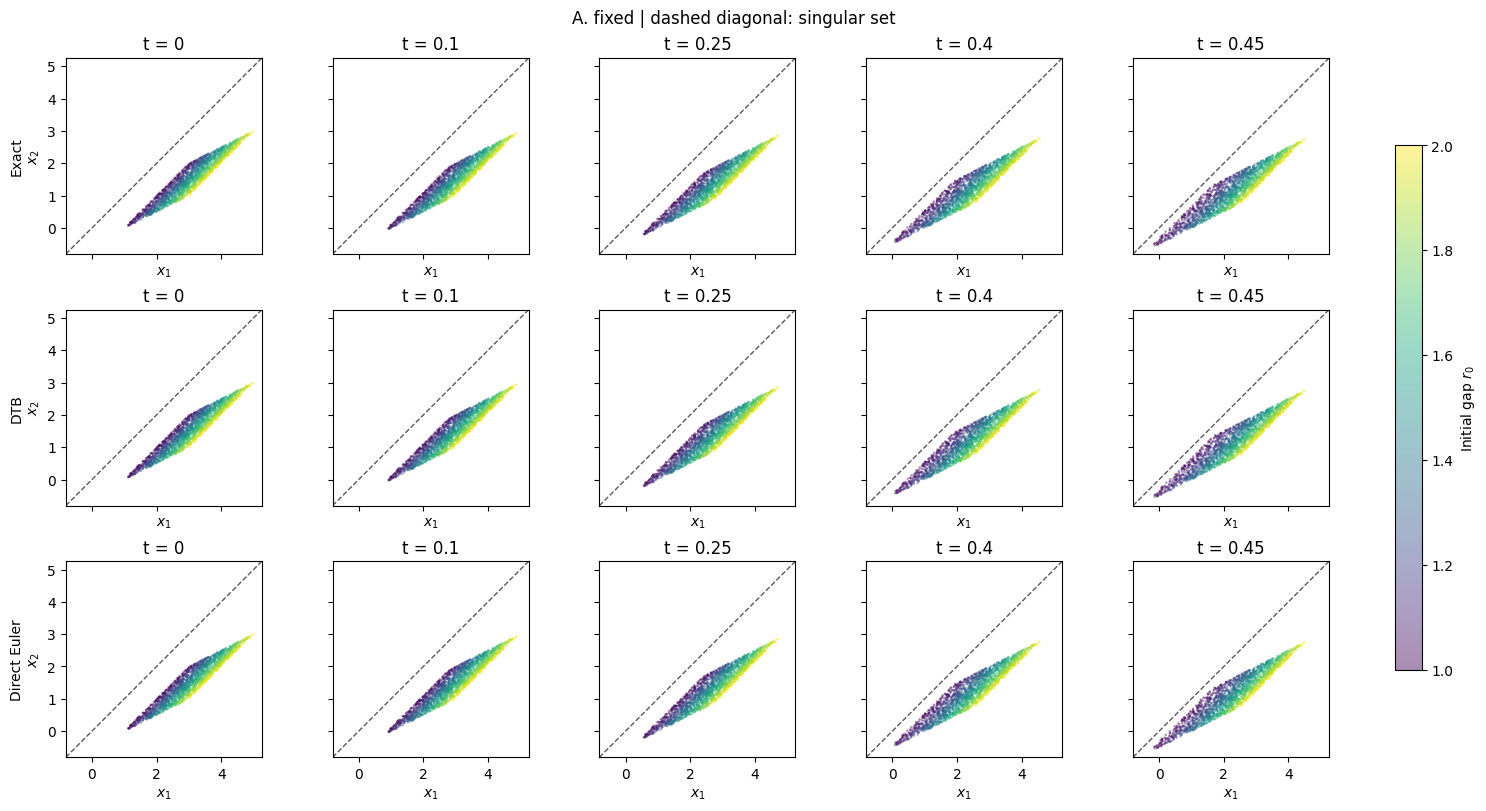

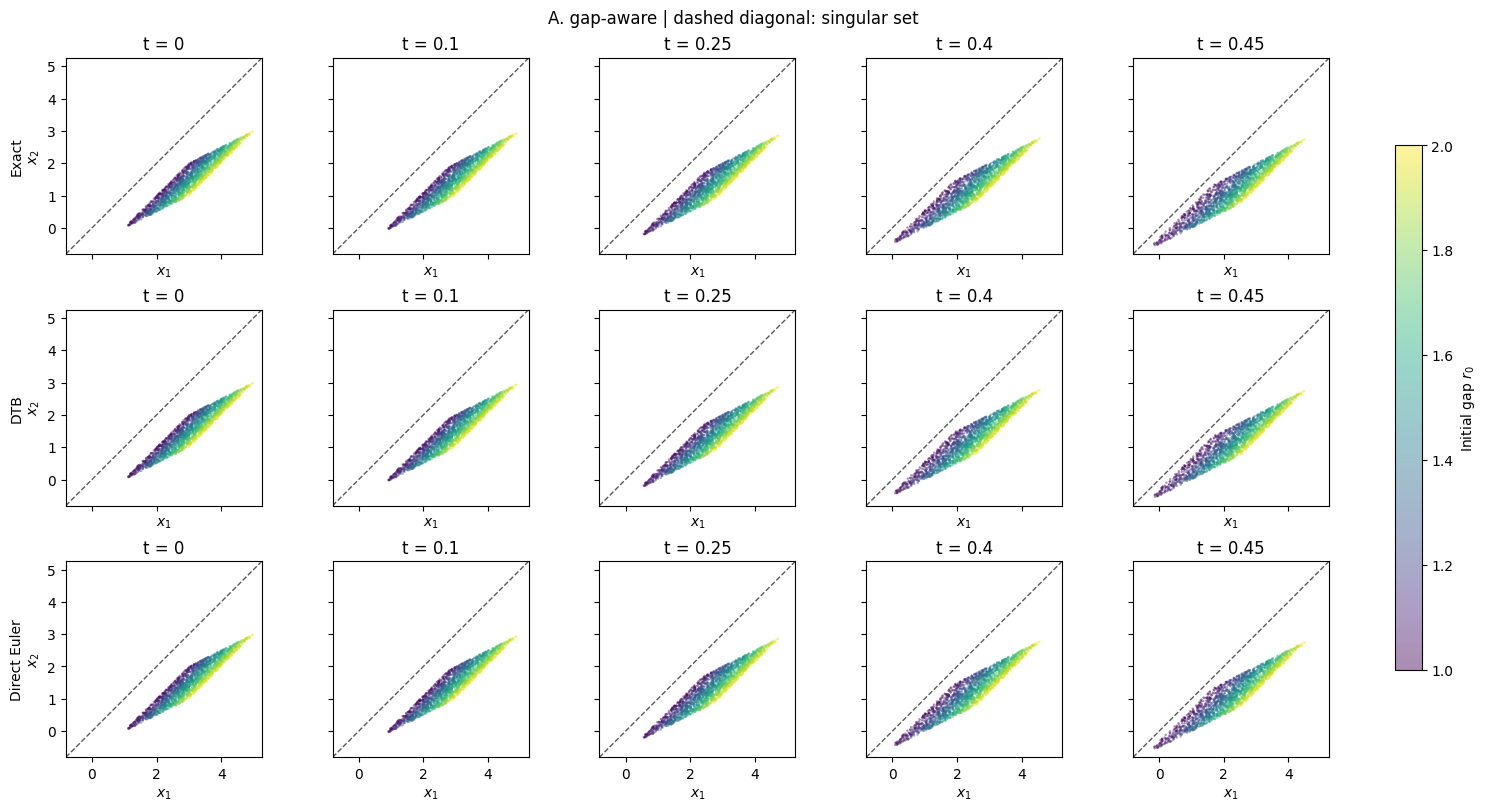

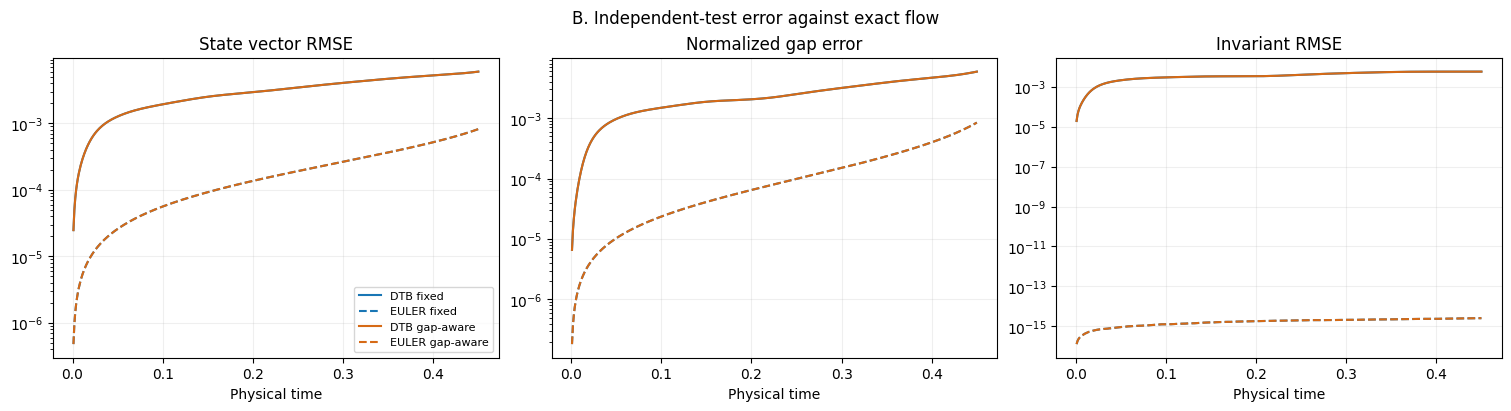

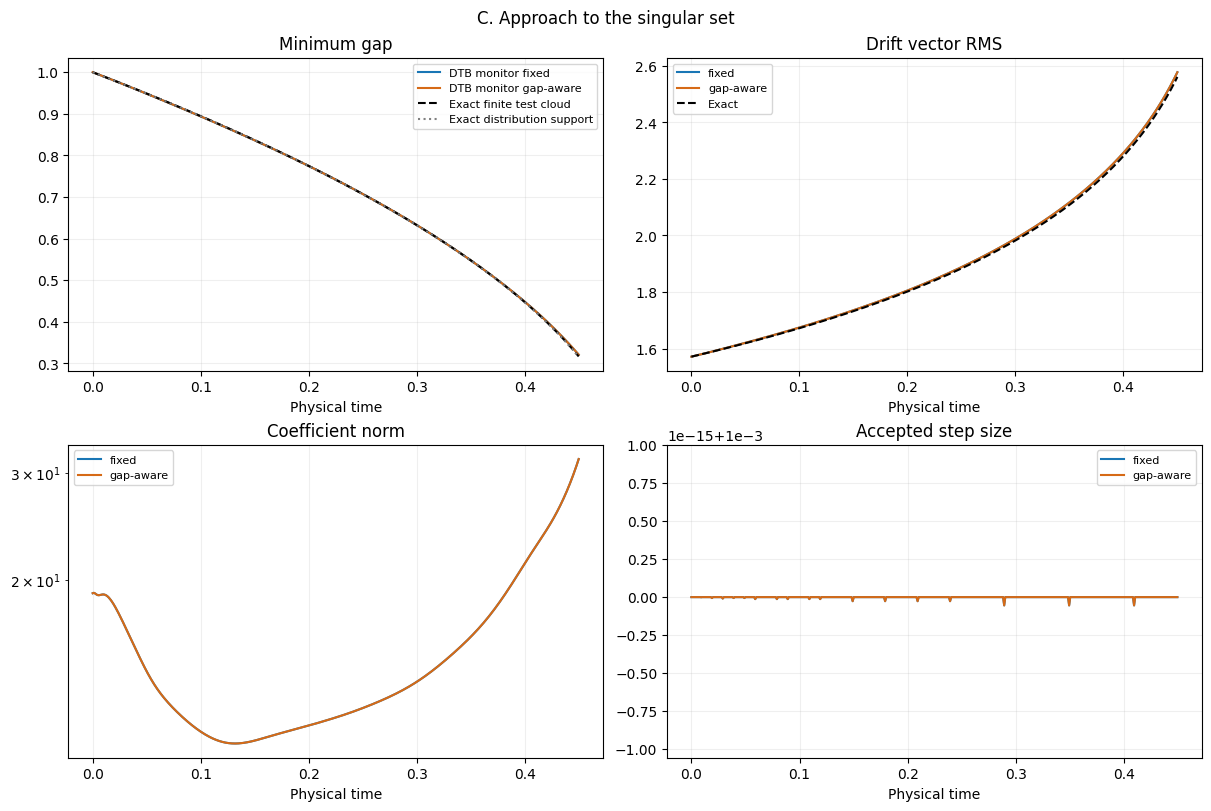

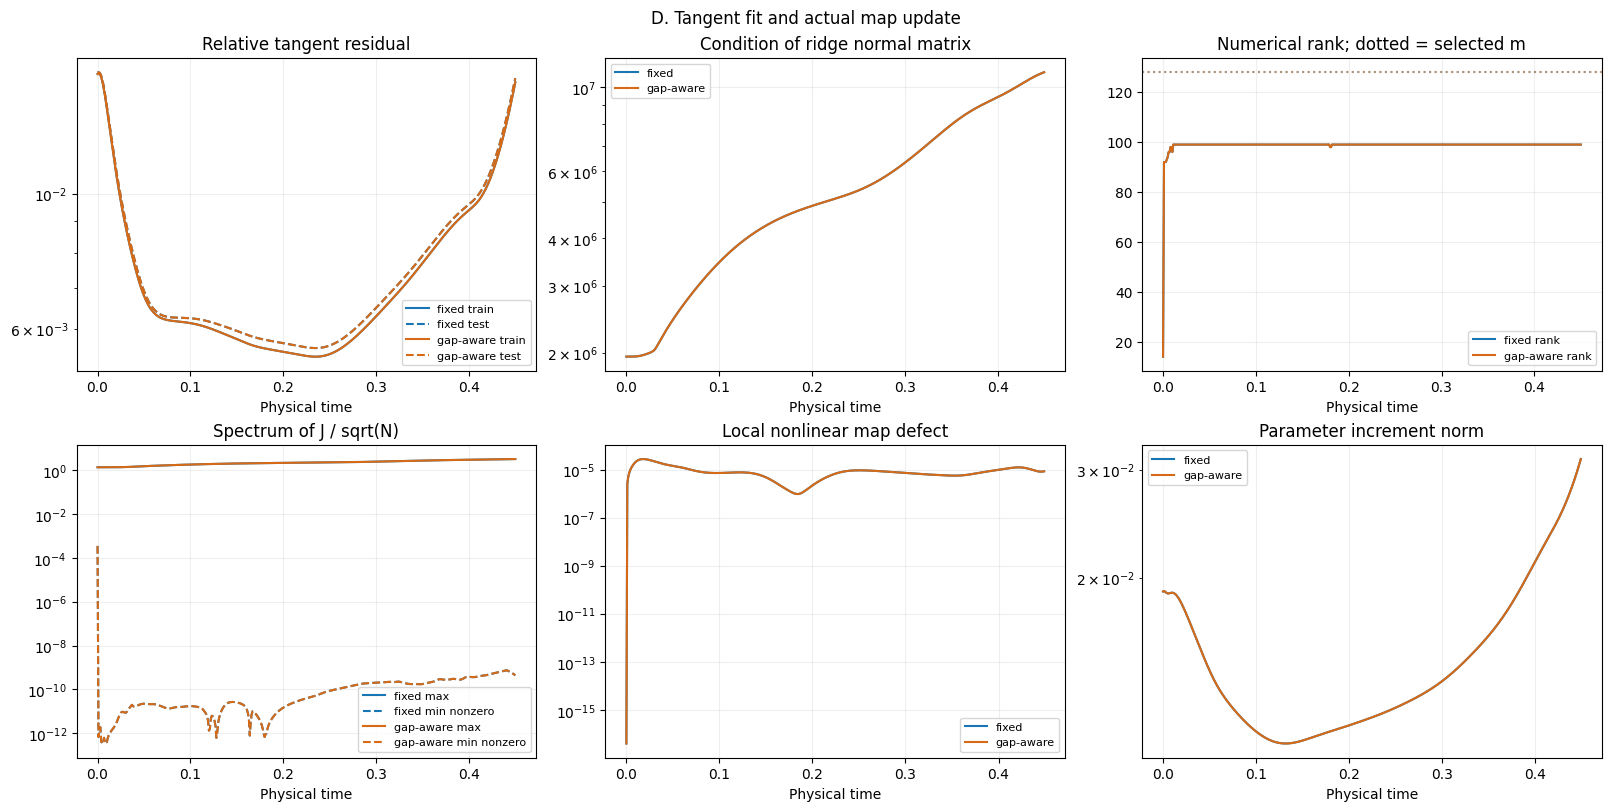

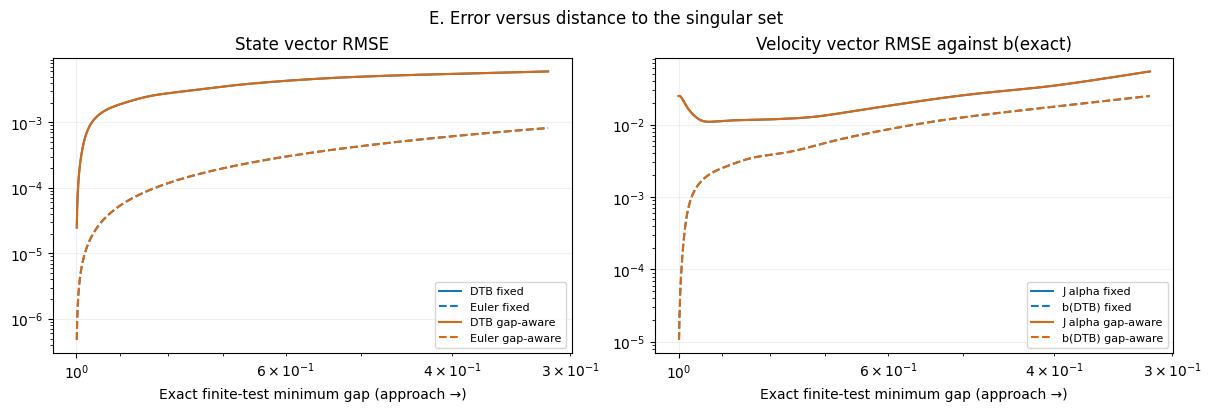

In [8]:
FIGURES = {}
COLORS = {'fixed': '#1976b5', 'gap-aware': '#d66a16'}

def positive_plot(values):
    values = np.asarray(values, dtype=float)
    return np.where(values > 0, values, np.nan)

def matched_index(times, t):
    indices = np.flatnonzero(np.isclose(times, t, atol=1e-11, rtol=0))
    return int(indices[0]) if len(indices) else None

def finish_figure(fig, name):
    FIGURES[name] = fig
    plt.show()

def plot_flow_snapshots(pair, name):
    result, euler = pair['dtb'], pair['euler']
    cfg = Config(**result['config'])
    shown = sorted(set([t for t in SNAPSHOT_TIMES if t <= cfg.t_final] + [cfg.t_final]))
    initial = result['test_initial']
    truths = [reference_for(cfg)(initial, t).numpy() for t in shown]
    all_values = np.concatenate([np.asarray(truths).ravel(), result['particles'].numpy().ravel(),
                                 euler['particles'].numpy().ravel()])
    lo, hi = float(all_values.min()), float(all_values.max())
    pad = 0.05 * max(hi - lo, 1)
    limits = (lo - pad, hi + pad)
    fig, axes = plt.subplots(3, len(shown), figsize=(3 * len(shown), 8),
                              sharex=True, sharey=True, squeeze=False, layout='constrained')
    for column, t in enumerate(shown):
        di = matched_index(result['snapshot_times'], t)
        ei = matched_index(euler['times'], t)
        clouds = [truths[column], None if di is None else result['particles'][di].numpy(),
                  None if ei is None else euler['particles'][ei].numpy()]
        for row, points in enumerate(clouds):
            ax = axes[row, column]
            ax.plot(limits, limits, '--', c='0.35', lw=1)
            ax.set(xlim=limits, ylim=limits, aspect='equal', xlabel='$x_1$')
            ax.set_title(f't = {t:.3g}')
            if column == 0:
                ax.set_ylabel(['Exact', 'DTB', 'Direct Euler'][row] + '\n$x_2$')
            if points is None:
                ax.text(.5, .5, 'Unavailable\nrun stopped', ha='center', va='center', transform=ax.transAxes)
            else:
                scatter = ax.scatter(points[:, 0], points[:, 1], c=gap(initial),
                                      vmin=1, vmax=2, cmap='viridis', s=3, alpha=.45,
                                      edgecolors='none', rasterized=True)
    fig.colorbar(scatter, ax=axes.ravel().tolist(), shrink=.75, label='Initial gap $r_0$')
    fig.suptitle(f'A. {name} | dashed diagonal: singular set')
    finish_figure(fig, f'flow_{name}')

for policy, pair in primary.items():
    plot_flow_snapshots(pair, policy)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), layout='constrained')
for policy, pair in primary.items():
    for method, result in pair.items():
        m = result['metrics']
        for ax, key, title in zip(axes, ['state_rmse', 'gap_relative', 'invariant_rmse'],
                                  ['State vector RMSE', 'Normalized gap error', 'Invariant RMSE']):
            ax.semilogy(m.time, positive_plot(m[key]), color=COLORS[policy],
                         ls='-' if method == 'dtb' else '--', label=f'{method.upper()} {policy}')
            ax.set(xlabel='Physical time', title=title)
            ax.grid(alpha=.2)
axes[0].legend(fontsize=8)
fig.suptitle('B. Independent-test error against exact flow')
finish_figure(fig, 'errors_time')

fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout='constrained')
for policy, pair in primary.items():
    m, steps = pair['dtb']['metrics'], pair['dtb']['steps']
    axes[0, 0].plot(m.time, m.min_gap_monitor, label=f'DTB monitor {policy}', c=COLORS[policy])
    axes[0, 1].plot(m.time, m.drift_rms, label=policy, c=COLORS[policy])
    axes[1, 0].semilogy(m.time, positive_plot(m.alpha_norm), label=policy, c=COLORS[policy])
    if not steps.empty:
        axes[1, 1].plot(steps.time, steps.step_size, label=policy, c=COLORS[policy])
m = primary['fixed']['dtb']['metrics']
axes[0, 0].plot(m.time, m.exact_min_gap_test, '--', c='black', label='Exact finite test cloud')
axes[0, 0].plot(m.time, m.support_min_gap, ':', c='gray', label='Exact distribution support')
axes[0, 1].plot(m.time, m.exact_drift_rms, '--', c='black', label='Exact')
for ax, title in zip(axes.ravel(), ['Minimum gap', 'Drift vector RMS', 'Coefficient norm', 'Accepted step size']):
    ax.set(xlabel='Physical time', title=title)
    ax.legend(fontsize=8)
    ax.grid(alpha=.2)
fig.suptitle('C. Approach to the singular set')
finish_figure(fig, 'singularity')

fig, axes = plt.subplots(2, 3, figsize=(16, 8), layout='constrained')
for policy, pair in primary.items():
    m, steps = pair['dtb']['metrics'], pair['dtb']['steps']
    for key, style in [('train_relative_residual', '-'), ('test_relative_residual', '--')]:
        axes[0, 0].semilogy(m.time, positive_plot(m[key]), style, c=COLORS[policy],
                            label=f'{policy} {key.split("_")[0]}')
    axes[0, 1].semilogy(m.time, m.ridge_normal_condition, label=policy, c=COLORS[policy])
    axes[0, 2].plot(m.time, m.numerical_rank, label=f'{policy} rank', c=COLORS[policy])
    axes[0, 2].axhline(m.selected_dimension.iloc[0], color=COLORS[policy], ls=':', alpha=.5)
    axes[1, 0].semilogy(m.time, positive_plot(m.sigma_max), c=COLORS[policy], label=f'{policy} max')
    axes[1, 0].semilogy(m.time, positive_plot(m.sigma_min_nonzero), '--', c=COLORS[policy], label=f'{policy} min nonzero')
    if not steps.empty:
        axes[1, 1].semilogy(steps.time, positive_plot(steps.map_step_defect), c=COLORS[policy], label=policy)
        axes[1, 2].semilogy(steps.time, positive_plot(steps.theta_increment_norm), c=COLORS[policy], label=policy)
for ax, title in zip(axes.ravel(), ['Relative tangent residual', 'Condition of ridge normal matrix',
                                    'Numerical rank; dotted = selected m', 'Spectrum of J / sqrt(N)',
                                    'Local nonlinear map defect', 'Parameter increment norm']):
    ax.set(xlabel='Physical time', title=title)
    ax.legend(fontsize=8)
    ax.grid(alpha=.2)
fig.suptitle('D. Tangent fit and actual map update')
finish_figure(fig, 'tangent_quality')

fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')
for policy, pair in primary.items():
    m = pair['dtb']['metrics']
    axes[0].loglog(m.exact_min_gap_test, positive_plot(m.state_rmse), c=COLORS[policy], label=f'DTB {policy}')
    em = pair['euler']['metrics']
    exact_gaps = [float(gap(exact_singular_flow(pair['dtb']['test_initial'], t)).min()) for t in em.time]
    axes[0].loglog(exact_gaps, positive_plot(em.state_rmse), '--', c=COLORS[policy], label=f'Euler {policy}')
    axes[1].loglog(m.exact_min_gap_test, positive_plot(m.velocity_rmse), c=COLORS[policy], label=f'J alpha {policy}')
    axes[1].loglog(m.exact_min_gap_test, positive_plot(m.drift_velocity_rmse), '--', c=COLORS[policy], label=f'b(DTB) {policy}')
for ax, title in zip(axes, ['State vector RMSE', 'Velocity vector RMSE against b(exact)']):
    ax.set(xlabel='Exact finite-test minimum gap (approach →)', title=title)
    ax.invert_xaxis()
    ax.legend(fontsize=8)
    ax.grid(alpha=.2)
fig.suptitle('E. Error versus distance to the singular set')
finish_figure(fig, 'errors_gap')


## 6. Optional full experiment matrix

Enable `RUN_FULL_STUDY` in the configuration cell and rerun from there. Each
scenario uses seeds 0, 1, 2, a fixed independent test cloud, and a freshly
initialized identity map. Runs to 0.49 also provide exact-time diagnostics at
0.45 and 0.48, avoiding repeated prefixes. The matrix varies one control at a
time: stepping policy, selected dimension $m\in\{32,64,128\}$, training count
$N\in\{256,512,1024\}$, and $h\in\{10^{-3},5\times10^{-4}\}$.

The table reports sample mean and sample standard deviation (`ddof=1`). A
failed or stopped run remains in the availability table. Statistics at a
requested horizon are reported only when **all three seeds reach it**; this
avoids presenting survivorship-biased comparisons. Seed standard deviation
does not include independent repetitions of the test sample.


In [9]:
study_runs, study_rows = {}, []
study_summary = pd.DataFrame()

# Cheap exact-flow baseline refinement is useful even in the short default run.
# This table separates ordinary Euler time error from neural-map effects near .5.
refinement_initial = primary['fixed']['dtb']['test_initial']
euler_refinement_rows = []
for h in (1e-3, 5e-4):
    baseline = direct_euler_singular(refinement_initial, [0, .45, .48, .49], h)
    for row in baseline['metrics'].iloc[1:].to_dict('records'):
        euler_refinement_rows.append({'step_size': h, **row})
euler_refinement = pd.DataFrame(euler_refinement_rows)
display(euler_refinement[['step_size', 'time', 'state_rmse', 'gap_relative', 'invariant_rmse']])

def collect_study_row(run, scenario, seed, horizon):
    index = matched_index(run['times'], horizon)
    row = {'scenario': scenario, 'seed': seed, 'horizon': horizon,
           'available': index is not None, 'run_status': run['status'],
           'stop_reason': run['stop_reason'], 'failed_time': run['failed_time'],
           'last_valid_time': float(run['times'][-1]) if len(run['times']) else float('nan'),
           'accepted_steps': len(run['steps']),
           'min_step_size': float(run['steps'].step_size.min()) if not run['steps'].empty else float('nan')}
    if index is not None:
        metrics = run['metrics'].iloc[index]
        row.update({k: float(metrics[k]) for k in (
            'state_rmse', 'gap_relative', 'invariant_rmse', 'velocity_rmse',
            'test_relative_residual', 'min_gap', 'elapsed_seconds')})
    return row

def aggregate_study(rows):
    records = pd.DataFrame(rows)
    output = []
    for (scenario, horizon), group in records.groupby(['scenario', 'horizon'], sort=False):
        valid = group[group.available]
        enough = len(valid) == len(STUDY_SEEDS)
        row = {'scenario': scenario, 'horizon': horizon,
               'available_seeds': len(valid), 'requested_seeds': len(STUDY_SEEDS)}
        for key in ('state_rmse', 'gap_relative', 'invariant_rmse', 'velocity_rmse'):
            row[key + '_mean'] = float(valid[key].mean()) if enough else float('nan')
            row[key + '_std'] = float(valid[key].std(ddof=1)) if enough else float('nan')
        output.append(row)
    return records, pd.DataFrame(output)

if RUN_FULL_STUDY:
    scenarios = {
        'fixed m128 N512 h.001': {},
        'gap-aware m128 N512 h.001': {'policy': 'gap-aware'},
        'fixed m32 N512 h.001': {'basis_size': 32},
        'fixed m64 N512 h.001': {'basis_size': 64},
        'fixed m128 N256 h.001': {'n_train': 256},
        'fixed m128 N1024 h.001': {'n_train': 1024},
        'fixed m128 N512 h.0005': {'h_max': 5e-4},
    }
    for scenario, overrides in scenarios.items():
        for seed in STUDY_SEEDS:
            controls = {'n_train': 512, 'basis_size': 128, 'h_max': .001, 'policy': 'fixed'}
            controls.update(overrides)
            cfg = replace(BASE, seed=seed, t_final=0.49, **controls)
            run = run_dtb(cfg, verbose=False)
            study_runs[(scenario, seed)] = run
            for horizon in (0.45, 0.48, 0.49):
                study_rows.append(collect_study_row(run, scenario, seed, horizon))
            print(scenario, 'seed', seed, run['status'],
                  f'{run["wall_seconds"]:.1f}s', run['stop_reason'])
    study_records, study_summary = aggregate_study(study_rows)
    display(study_records[['scenario', 'seed', 'horizon', 'available', 'run_status', 'stop_reason']])
    display(study_summary)
    # Show the actual approach-to-collision snapshots through .49 for seed zero.
    # The Euler baseline again follows that run's accepted physical time grid.
    for policy in ('fixed', 'gap-aware'):
        scenario = f'{policy} m128 N512 h.001'
        run = study_runs[(scenario, STUDY_SEEDS[0])]
        baseline = direct_euler_singular(run['test_initial'], run['times'], BASE.h_max)
        plot_flow_snapshots({'dtb': run, 'euler': baseline}, f'approach_{policy}')
    # Plot only complete three-seed groups. Error bars denote sample SD.
    final = study_summary[study_summary.horizon == 0.49]
    fig, ax = plt.subplots(figsize=(11, 5), layout='constrained')
    for i, row in final.reset_index(drop=True).iterrows():
        if row.available_seeds == len(STUDY_SEEDS):
            ax.errorbar(i, row.state_rmse_mean, yerr=row.state_rmse_std,
                         fmt='o', capsize=5, color='#1976b5')
        else:
            ax.text(i, .02, f'{row.available_seeds}/3 available', rotation=90,
                     transform=ax.get_xaxis_transform(), ha='center')
    ax.set_xticks(range(len(final)), final.scenario, rotation=25, ha='right')
    ax.set(ylabel='State vector RMSE', title='t=0.49: mean ± sample SD across three seeds')
    ax.grid(axis='y', alpha=.2)
    finish_figure(fig, 'study_final_error')
else:
    print('Full matrix disabled for the short default run; set RUN_FULL_STUDY=True to execute it.')


,step_size,time,state_rmse,gap_relative,invariant_rmse
0,0.0010,0.45,0.000818,0.000843,2.492993e-15
1,0.0010,0.48,0.001264,0.001913,2.584101e-15
2,0.0010,0.49,0.001621,0.003271,2.617059e-15
3,0.0005,0.45,0.000410,0.000423,3.746834e-15
4,0.0005,0.48,0.000635,0.000964,3.781964e-15
5,0.0005,0.49,0.000819,0.001660,3.820390e-15


Full matrix disabled for the short default run; set RUN_FULL_STUDY=True to execute it.


## 7. Regularized companion: a different dynamical system

After the singular benchmark, compare

$$
b_\varepsilon(x)=\begin{pmatrix}-2r/(r^2+\varepsilon^2)\\-r/(r^2+\varepsilon^2)\end{pmatrix},
\qquad
\frac12r(t)^2+\varepsilon^2\log r(t)
=\frac12r_0^2+\varepsilon^2\log r_0-t.
$$

The bracketed log-gap bisection above supplies this system's exact reference.
Regularized DTB and Euler are compared with **their own** exact dynamics.
The additional difference between regularized exact flow and singular exact
flow is labeled model bias; it is not numerical error. Default companion
runs use seed 0. With the full study enabled, each epsilon uses all three seeds.
The plotted horizon stays at 0.49 to permit comparison with the singular flow.


Regularized epsilon 0.2 seed 0 completed 
Regularized epsilon 0.1 seed 0 completed 
Regularized epsilon 0.05 seed 0 completed 


,method,status,final_time,state_rmse,gap_relative,invariant_rmse,min_gap,runtime_seconds,stop_reason
0,"DTB fixed, eps=0.2, seed=0",completed,0.49,0.004966,0.005090,5.328388e-03,0.330457,32.387850,
1,"Direct Euler, eps=0.2, seed=0",completed,0.49,0.000605,0.000568,2.819057e-15,0.331051,5.267090,
2,"DTB fixed, eps=0.1, seed=0",completed,0.49,0.006369,0.007058,5.684808e-03,0.230541,32.688569,
3,"Direct Euler, eps=0.1, seed=0",completed,0.49,0.001034,0.001387,2.572425e-15,0.226548,5.313453,
4,"DTB fixed, eps=0.05, seed=0",completed,0.49,0.007576,0.009156,5.610960e-03,0.185878,32.393490,
5,"Direct Euler, eps=0.05, seed=0",completed,0.49,0.001377,0.002359,2.681088e-15,0.175163,5.257343,


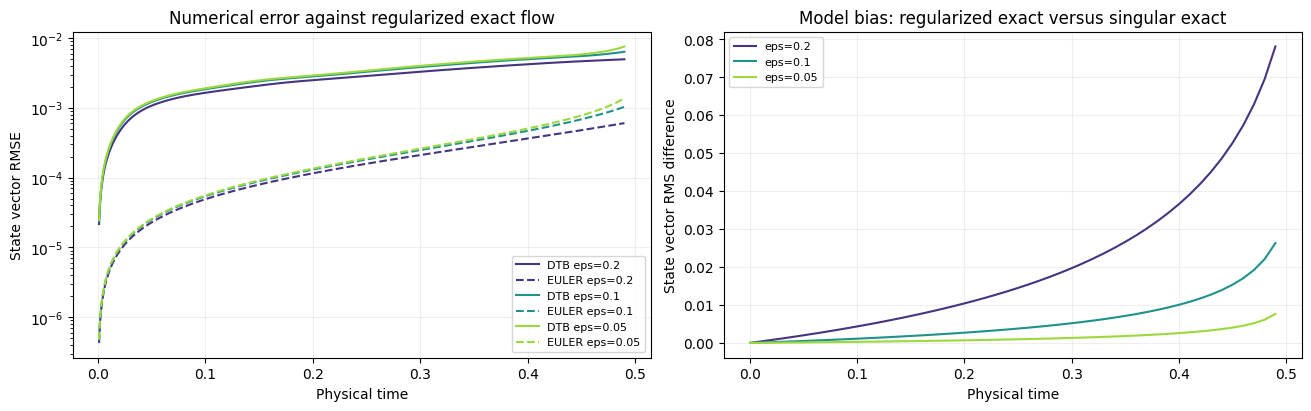

In [10]:
regularized_runs, regularized_rows = {}, []
regularized_summary = pd.DataFrame()
if RUN_REGULARIZED:
    for eps in REGULARIZED_EPSILONS:
        for seed in (STUDY_SEEDS if RUN_FULL_STUDY else (BASE.seed,)):
            cfg = replace(BASE, seed=seed, epsilon=eps, t_final=0.49, policy='fixed')
            run = run_dtb(cfg, verbose=False)
            euler = direct_euler_singular(run['test_initial'], run['times'], cfg.h_max,
                                          epsilon=eps, r_stop=cfg.r_stop)
            regularized_runs[(eps, seed)] = {'dtb': run, 'euler': euler}
            regularized_rows.append(collect_study_row(run, f'epsilon={eps}', seed, 0.49))
            print('Regularized epsilon', eps, 'seed', seed, run['status'], run['stop_reason'])
    display(pd.DataFrame([summary_row(r, f'{r["method"]}, eps={eps}, seed={seed}')
                          for (eps, seed), pair in regularized_runs.items() for r in pair.values()]))
    if RUN_FULL_STUDY:
        regularized_records, regularized_summary = aggregate_study(regularized_rows)
        display(regularized_summary)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), layout='constrained')
    plot_seed = STUDY_SEEDS[0] if RUN_FULL_STUDY else BASE.seed
    for color_index, eps in enumerate(REGULARIZED_EPSILONS):
        pair = regularized_runs[(eps, plot_seed)]
        color = plt.get_cmap('viridis')(0.15 + 0.35 * color_index)
        for method, run in pair.items():
            metrics = run['metrics']
            axes[0].semilogy(metrics.time, positive_plot(metrics.state_rmse),
                             ls='-' if method == 'dtb' else '--', color=color, label=f'{method.upper()} eps={eps}')
        test = pair['dtb']['test_initial']
        times = pair['dtb']['snapshot_times']
        bias = [vector_rms(exact_regularized_flow(test, t, eps) - exact_singular_flow(test, t)) for t in times]
        axes[1].plot(times, bias, color=color, label=f'eps={eps}')
    axes[0].set(title='Numerical error against regularized exact flow', ylabel='State vector RMSE')
    axes[1].set(title='Model bias: regularized exact versus singular exact', ylabel='State vector RMS difference')
    for ax in axes:
        ax.set_xlabel('Physical time')
        ax.legend(fontsize=8)
        ax.grid(alpha=.2)
    finish_figure(fig, 'regularized_comparison')


## 8. Conclusions and limits of interpretation

The following cell reports what the current run actually reached, including
numerical failures. Increasing error near a small gap is plausible but is not
assumed: inspect the measured curves, the step-size comparison, and the seed
variation before drawing a conclusion. Fixed and gap-aware schedules may be
identical at 0.45 if the gap cap never activates.

Here $\|b(x)\|^2=5/r^2$. A distribution with positive density arbitrarily close
to $r=0$ can have a non-integrable squared drift. The field is not globally
Lipschitz on its domain, so these numerical experiments do not establish a
global-Lipschitz DTB theorem for this benchmark.


In [11]:
for policy, pair in primary.items():
    run, euler = pair['dtb'], pair['euler']
    m = run['metrics']
    last = m.iloc[-1]
    print(f'{policy}: reached t={last.time:.6f}; DTB state RMSE={last.state_rmse:.3e}; '
          f'normalized gap error={last.gap_relative:.3e}; '
          f'test tangent residual={last.test_relative_residual:.3e}.')
    ei = matched_index(euler['times'], last.time)
    if ei is not None:
        print(f'  Same-time direct Euler state RMSE={euler["metrics"].iloc[ei].state_rmse:.3e}.')
    if not run['steps'].empty:
        h = run['steps'].step_size
        print(f'  Accepted steps={len(h)}, h range=[{h.min():.3g}, {h.max():.3g}], '
              f'max local nonlinear map defect={run["steps"].map_step_defect.max():.3e}.')
    if run['status'] != 'completed':
        print('  Run', run['status'], '| reason:', run['stop_reason'], '| failed proposal time:', run['failed_time'])
if not RUN_FULL_STUDY:
    print('These primary results use one seed; no multi-seed accuracy claim is made.')

def export_result(folder, run):
    """Use repository serialization, with CSVs for the complete diagnostic tables."""
    folder.mkdir(parents=True, exist_ok=True)
    config = {**run['config'], 'method': run['method'], 'status': run['status'],
              'stop_reason': run['stop_reason'], 'failed_time': run['failed_time'],
              'dtype': str(DTYPE), 'device': str(DEVICE), 'diffusion': 0.0,
              'parameter_count': run['parameter_count'], 'wall_seconds': run['wall_seconds'],
              'selected_parameter_indices': run['selected'].tolist()}
    arrays = {name: run[name] for name in ('times', 'snapshot_times', 'particles', 'test_initial',
                                          'train_initial', 'theta_initial', 'theta_final', 'selected')}
    save_run_data(folder, config=config, arrays=arrays,
                   metrics_markdown='Diagnostics: metrics.csv; accepted updates: steps.csv.\n'
                   'Official states are evaluations of the updated neural map on fixed labels.')
    run['metrics'].to_csv(folder / 'metrics.csv', index=False)
    run['steps'].to_csv(folder / 'steps.csv', index=False)
    if run['failure_proposal'] is not None:
        proposal = run['failure_proposal']
        if proposal['test_particles'] is not None:
            np.save(folder / 'rejected_test_proposal.npy', proposal['test_particles'].numpy())

if SAVE_RUN:
    from datetime import datetime, timezone
    output_dir = EXPERIMENT_DIR / 'saved_runs' / (
        'singular-game-2d__' + datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S-%fZ'))
    for policy, pair in primary.items():
        export_result(output_dir / policy, pair['dtb'])
        pair['euler']['metrics'].to_csv(output_dir / policy / 'euler_metrics.csv', index=False)
        np.savez_compressed(output_dir / policy / 'euler_history.npz',
                            times=pair['euler']['times'], particles=pair['euler']['particles'].numpy())
    for (scenario, seed), run in study_runs.items():
        export_result(output_dir / 'study' / scenario.replace(' ', '_') / f'seed-{seed}', run)
    for (eps, seed), pair in regularized_runs.items():
        export_result(output_dir / 'regularized' / f'eps-{eps}_seed-{seed}', pair['dtb'])
        pair['euler']['metrics'].to_csv(output_dir / 'regularized' / f'eps-{eps}_seed-{seed}' / 'euler_metrics.csv', index=False)
    for name, figure in FIGURES.items():
        figure.savefig(output_dir / f'{name}.png', dpi=150, bbox_inches='tight')
    summary.to_csv(output_dir / 'summary.csv', index=False)
    study_summary.to_csv(output_dir / 'study_summary.csv', index=False)
    regularized_summary.to_csv(output_dir / 'regularized_summary.csv', index=False)
    euler_refinement.to_csv(output_dir / 'euler_refinement.csv', index=False)
    if study_rows:
        pd.DataFrame(study_rows).to_csv(output_dir / 'study_runs.csv', index=False)
    if regularized_rows:
        pd.DataFrame(regularized_rows).to_csv(output_dir / 'regularized_runs.csv', index=False)
    print('Saved:', output_dir)


fixed: reached t=0.450000; DTB state RMSE=5.980e-03; normalized gap error=5.874e-03; test tangent residual=1.546e-02.
  Same-time direct Euler state RMSE=8.184e-04.
  Accepted steps=450, h range=[0.001, 0.001], max local nonlinear map defect=2.733e-05.
gap-aware: reached t=0.450000; DTB state RMSE=5.980e-03; normalized gap error=5.874e-03; test tangent residual=1.546e-02.
  Same-time direct Euler state RMSE=8.184e-04.
  Accepted steps=450, h range=[0.001, 0.001], max local nonlinear map defect=2.733e-05.
These primary results use one seed; no multi-seed accuracy claim is made.


## Recorded validation

The short run above and all 11 acceptance tests were executed successfully. A separate full study ran 21 unregularized and nine regularized DTB configurations. The following recorded results use the default architecture and three seeds; they are not recomputed when `RUN_FULL_STUDY=False`.

| Scenario | Time | Seeds reaching time | State RMSE | Relative gap error |
|---|---:|---:|---:|---:|
| fixed m128 N512 h.001 | 0.49 | 3/3 | 0.01259 ± 0.00509 | 0.02189 ± 0.00918 |
| gap-aware m128 N512 h.001 | 0.49 | 3/3 | 0.01254 ± 0.00509 | 0.02187 ± 0.00923 |
| fixed m32 N512 h.001 | 0.49 | 2/3 | Unavailable | Unavailable |
| fixed m64 N512 h.001 | 0.49 | 2/3 | Unavailable | Unavailable |
| fixed m128 N256 h.001 | 0.49 | 3/3 | 0.01304 ± 0.00525 | 0.02215 ± 0.0089 |
| fixed m128 N1024 h.001 | 0.49 | 3/3 | 0.01147 ± 0.00384 | 0.01882 ± 0.00641 |
| fixed m128 N512 h.0005 | 0.49 | 3/3 | 0.01171 ± 0.00409 | 0.02019 ± 0.00816 |

- `fixed m32 N512 h.001`, seed 1: **stopped** at last valid time 0.437; minimum monitored gap below r_stop=0.02.
- `fixed m64 N512 h.001`, seed 1: **failed** at last valid time 0.487; proposed test state reaches or crosses x1=x2 (leaves the positive-gap branch) (rejected proposal time 0.488).

See [the validation report](singular_game_validation/README.md) for full tables, exact stopping times, diagnostic CSVs, figures, and environment details.


## 9. Implementation notes / deviations

- **Existing helpers reused:** `flat_params`, `write_flat_into_model` (`dtb.py`);
  `ResidualMLPMap`, `map_at`, `game_dtb_basis_matrices` (`run_game_dtb.py`);
  `count_trainable` (`network.py`); `save_run_data` (`utility.py`). Inspected
  the parameter-evolving, accumulated-map, and 3D stochastic DTB/Euler examples.
- **Files:** this notebook, its acceptance-test script, and its experiment
  README are added. Shared framework modules and prior notebooks are unchanged.
  No helper is added to `utility.py`; the short ridge solver stays visible here.
- **Architecture:** residual tanh MLP $2\to16\to16\to2$, 354 parameters,
  zero output initialization, fixed reference labels, no refitting or resetting.
- **Basis:** one seeded random coordinate subset, default $m=128$, recomputed
  Jacobian at each parameter state. Smaller subsets are nested within larger
  ones for a given seed. Selected coordinate indices are saved with every run.
- **Solver:** SVD ridge with $\eta=10^{-6}$ and $1/N$ normalization. The existing
  unregularized scalar/PDE solver is not used: its truncation would change this
  objective. Numerical rank is diagnostic only. Test velocity uses a JVP.
- **Time policy:** fixed or $\min(h_{max},\gamma r_{min}^2)$, shortened to land on
  stored times; $h_{max}=10^{-3}$, $\gamma=0.02$, $r_{stop}=0.02$. Both training
  and test states are monitored. No denominator floor or rejected-step retry.
- **Failure policy:** nonfinite or nonpositive-gap proposals fail explicitly;
  the last valid state is retained. Gap threshold or iteration limit produces
  a separate stopped status. The printed status and saved tables report actual
  failures, including failures in optional studies; missing horizons stay missing.
- **Scope choices:** the short default uses Stage 1 and regularized companions.
  Stages 2–5 are available behind `RUN_FULL_STUDY`; a fixed-step DTB halving
  experiment is included to support time-error interpretation. No score,
  diffusion, or stochastic extension is included. The regularized root solve
  uses bracketed bisection in log-gap to avoid a SciPy dependency.
- **Interpretation:** map-step defect is curvature, not a best-approximation
  representation bound. This notebook supplies complementary error diagnostics,
  not a uniquely additive separation of all error sources.
